<a href="https://colab.research.google.com/github/Lestrada93/diabetes-clasificacion-ml/blob/main/notebooks/diabetes_clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación y Validación de Modelos de Clasificación
## Predicción de Diabetes Tipo 2 | Dataset Pima Indians Diabetes
**Gestión de Proyectos de Inteligencia Artificial — Universidad Tecmilenio**

---
**Modelos comparados:** Regresión Logística (Baseline) vs. Random Forest  
**Objetivo SMART:** Desarrollar un modelo de clasificación para detección temprana de diabetes con un **recall ≥ 80%** y una **especificidad ≥ 70%**, evaluado mediante validación cruzada de 10 pliegues, en un período de una semana de experimentación.


## 1. Importación de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, precision_recall_curve,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Estilo visual
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 100
print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


## 2. Carga y Exploración del Dataset

In [ ]:
from google.colab import files
import os

# Sube tu kaggle.json cuando aparezca el botón
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

# Descarga el dataset
!pip install kaggle -q
!kaggle datasets download -d uciml/pima-indians-diabetes-database --unzip

df = pd.read_csv('diabetes.csv')
COLS = df.columns.tolist()
print(df.shape)
df.head()


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
License(s): CC0-1.0
100% 8.91k/8.91k [00:00<00:00, 18.1MB/s]

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("=== Estadísticas descriptivas ===")
df.describe().round(2)


=== Estadísticas descriptivas ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [ ]:
print("=== Valores nulos ===")
print(df.isnull().sum())

# Columnas con ceros que son biológicamente imposibles
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("\n=== Ceros en columnas críticas (valores imputados como missing) ===")
for c in zero_cols:
    n = (df[c] == 0).sum()
    print(f"  {c}: {n} ceros ({n/len(df)*100:.1f}%)")


=== Valores nulos ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

=== Ceros en columnas críticas (valores imputados como missing) ===
  Glucose: 5 ceros (0.7%)
  BloodPressure: 35 ceros (4.6%)
  SkinThickness: 227 ceros (29.6%)
  Insulin: 374 ceros (48.7%)
  BMI: 11 ceros (1.4%)


In [ ]:
# Reemplazar ceros por mediana en columnas críticas
for c in zero_cols:
    median_val = df[c][df[c] != 0].median()
    df[c] = df[c].replace(0, median_val)

print("✅ Ceros reemplazados por la mediana de cada variable")

# Distribución de clases
counts = df['Outcome'].value_counts()
print(f"\n=== Distribución de clases ===")
print(f"  Sin diabetes (0): {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"  Con diabetes (1): {counts[1]} ({counts[1]/len(df)*100:.1f}%)")


✅ Ceros reemplazados por la mediana de cada variable

=== Distribución de clases ===
  Sin diabetes (0): 500 (65.1%)
  Con diabetes (1): 268 (34.9%)


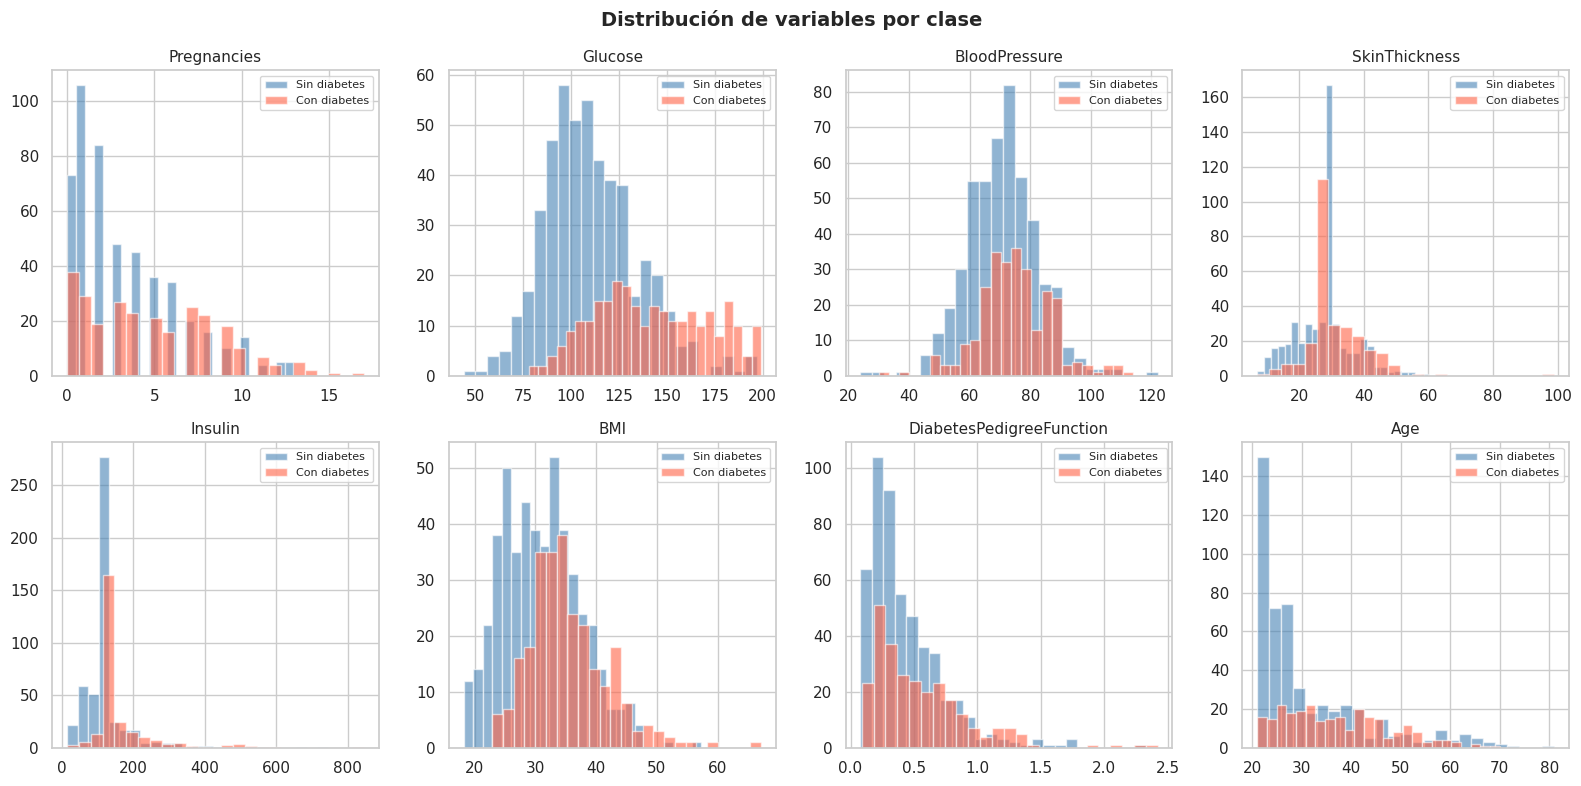

✅ Gráfica guardada como eda_distribucion.png


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
features = [c for c in COLS if c != 'Outcome']

for i, col in enumerate(features):
    axes[i].hist(df[df['Outcome']==0][col], alpha=0.6, label='Sin diabetes', bins=25, color='steelblue')
    axes[i].hist(df[df['Outcome']==1][col], alpha=0.6, label='Con diabetes', bins=25, color='tomato')
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)

plt.suptitle("Distribución de variables por clase", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_distribucion.png", bbox_inches='tight')
plt.show()
print("✅ Gráfica guardada como eda_distribucion.png")


## 3. Preparación de Datos y Entrenamiento de Modelos

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")
print(f"Positivos en test: {y_test.sum()} ({y_test.mean()*100:.1f}%)")


Train: 614 muestras | Test: 154 muestras
Positivos en test: 54 (35.1%)


In [ ]:
# Modelo 1 — Regresión Logística (Baseline)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

# Modelo 2 — Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=8,
                             random_state=42, class_weight='balanced')
rf.fit(X_train_sc, y_train)

print("✅ Modelos entrenados correctamente")


✅ Modelos entrenados correctamente


## 4. Métricas y Matriz de Confusión (Umbral 0.50)

In [ ]:
def calcular_metricas(nombre, modelo, X, y_true, umbral=0.50):
    proba = modelo.predict_proba(X)[:, 1]
    y_pred = (proba >= umbral).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc_val = roc_auc_score(y_true, proba)

    print(f"\n{'='*55}")
    print(f"  {nombre} | Umbral = {umbral}")
    print(f"{'='*55}")
    print(f"  Accuracy    : {acc:.4f}")
    print(f"  Precision   : {prec:.4f}")
    print(f"  Recall      : {rec:.4f}  {'✅' if rec >= 0.80 else '❌'} (meta ≥ 0.80)")
    print(f"  Especificidad: {spec:.4f}  {'✅' if spec >= 0.70 else '❌'} (meta ≥ 0.70)")
    print(f"  F1-Score    : {f1:.4f}")
    print(f"  ROC-AUC     : {auc_val:.4f}")
    print(f"\n  Matriz de confusión:")
    print(f"    TN={tn}  FP={fp}")
    print(f"    FN={fn}  TP={tp}")
    print(f"\n  FP (falsa alarma): {fp} pacientes sanos clasificados como diabéticos")
    print(f"  FN (caso perdido): {fn} diabéticos NO detectados (costo clínico alto)")

    return {'nombre': nombre, 'umbral': umbral, 'cm': cm,
            'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1,
            'spec': spec, 'auc': auc_val,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp}

res_lr_50 = calcular_metricas("Regresión Logística", lr, X_test_sc, y_test)
res_rf_50 = calcular_metricas("Random Forest", rf, X_test_sc, y_test)



  Regresión Logística | Umbral = 0.5
  Accuracy    : 0.7078
  Precision   : 0.6000
  Recall      : 0.5000  ❌ (meta ≥ 0.80)
  Especificidad: 0.8200  ✅ (meta ≥ 0.70)
  F1-Score    : 0.5455
  ROC-AUC     : 0.8130

  Matriz de confusión:
    TN=82  FP=18
    FN=27  TP=27

  FP (falsa alarma): 18 pacientes sanos clasificados como diabéticos
  FN (caso perdido): 27 diabéticos NO detectados (costo clínico alto)

  Random Forest | Umbral = 0.5
  Accuracy    : 0.7532
  Precision   : 0.6333
  Recall      : 0.7037  ❌ (meta ≥ 0.80)
  Especificidad: 0.7800  ✅ (meta ≥ 0.70)
  F1-Score    : 0.6667
  ROC-AUC     : 0.8261

  Matriz de confusión:
    TN=78  FP=22
    FN=16  TP=38

  FP (falsa alarma): 22 pacientes sanos clasificados como diabéticos
  FN (caso perdido): 16 diabéticos NO detectados (costo clínico alto)


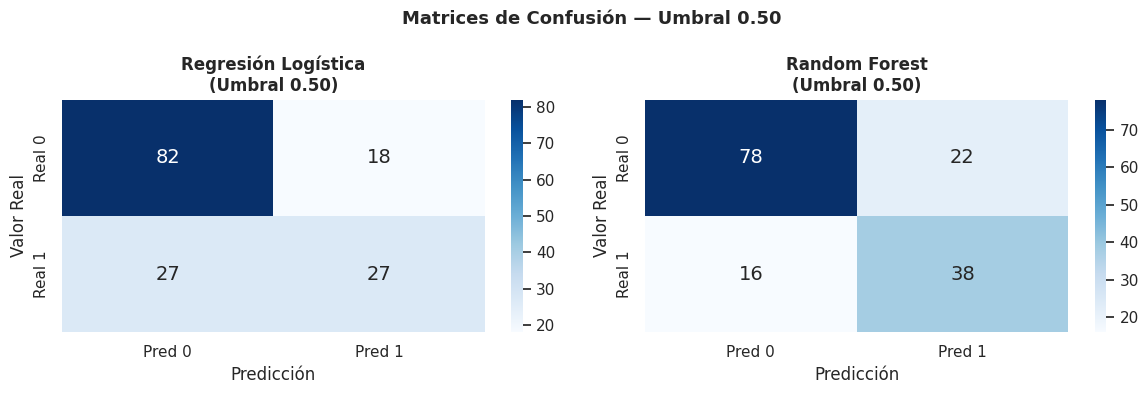

✅ Guardada confusion_matrix_050.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
modelos = [("Regresión Logística\n(Umbral 0.50)", res_lr_50['cm']),
           ("Random Forest\n(Umbral 0.50)", res_rf_50['cm'])]

for ax, (titulo, cm) in zip(axes, modelos):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Real 0', 'Real 1'], annot_kws={'size': 14})
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel("Valor Real")
    ax.set_xlabel("Predicción")

plt.suptitle("Matrices de Confusión — Umbral 0.50", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrix_050.png", bbox_inches='tight')
plt.show()
print("✅ Guardada confusion_matrix_050.png")


## 5. Curva ROC y AUC

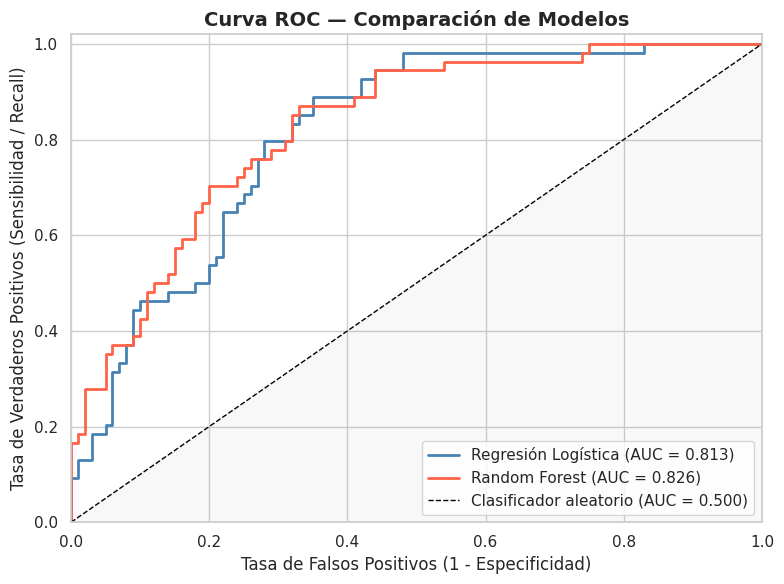

✅ Guardada roc_curve.png

Interpretación: Un AUC cercano a 1.0 indica excelente capacidad discriminativa.
Ambos modelos superan ampliamente al clasificador aleatorio (AUC = 0.5).


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for nombre, modelo, color in [("Regresión Logística", lr, 'steelblue'),
                               ("Random Forest",       rf, 'tomato')]:
    proba = modelo.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC = {auc_val:.3f})", color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label="Clasificador aleatorio (AUC = 0.500)")
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel("Tasa de Falsos Positivos (1 - Especificidad)", fontsize=12)
ax.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad / Recall)", fontsize=12)
ax.set_title("Curva ROC — Comparación de Modelos", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig("roc_curve.png", bbox_inches='tight')
plt.show()
print("✅ Guardada roc_curve.png")
print()
print("Interpretación: Un AUC cercano a 1.0 indica excelente capacidad discriminativa.")
print("Ambos modelos superan ampliamente al clasificador aleatorio (AUC = 0.5).")


## 6. Ajuste de Umbral — Maximizar Recall con Especificidad Aceptable

In [ ]:
def encontrar_umbral_optimo(modelo, X, y, nombre, min_recall=0.80, min_spec=0.70):
    proba = modelo.predict_proba(X)[:, 1]
    umbrales = np.arange(0.20, 0.81, 0.01)
    resultados = []

    for u in umbrales:
        y_pred = (proba >= u).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0,1]).ravel()
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1   = f1_score(y, y_pred, zero_division=0)
        resultados.append({'umbral': u, 'recall': rec, 'especificidad': spec, 'f1': f1})

    df_res = pd.DataFrame(resultados)
    # Filtrar umbrales que cumplan las metas
    df_ok = df_res[(df_res['recall'] >= min_recall) & (df_res['especificidad'] >= min_spec)]
    if not df_ok.empty:
        mejor = df_ok.loc[df_ok['f1'].idxmax()]
        print(f"\n{nombre} — Umbral óptimo encontrado: {mejor['umbral']:.2f}")
        print(f"  Recall       = {mejor['recall']:.4f} ✅")
        print(f"  Especificidad = {mejor['especificidad']:.4f} ✅")
        print(f"  F1-Score     = {mejor['f1']:.4f}")
    else:
        mejor = df_res.loc[df_res['recall'].idxmax()]
        print(f"\n{nombre} — No se encontró umbral que cumpla ambas metas simultáneamente.")
        print(f"  Umbral con mayor recall: {mejor['umbral']:.2f}")
        print(f"  Recall       = {mejor['recall']:.4f}")
        print(f"  Especificidad = {mejor['especificidad']:.4f}")

    return df_res, mejor['umbral']

df_lr_thresh, umbral_optimo_lr = encontrar_umbral_optimo(lr, X_test_sc, y_test, "Regresión Logística")
df_rf_thresh, umbral_optimo_rf = encontrar_umbral_optimo(rf, X_test_sc, y_test, "Random Forest")



Regresión Logística — No se encontró umbral que cumpla ambas metas simultáneamente.
  Umbral con mayor recall: 0.20
  Recall       = 0.8889
  Especificidad = 0.6100

Random Forest — No se encontró umbral que cumpla ambas metas simultáneamente.
  Umbral con mayor recall: 0.20
  Recall       = 0.9444
  Especificidad = 0.5400


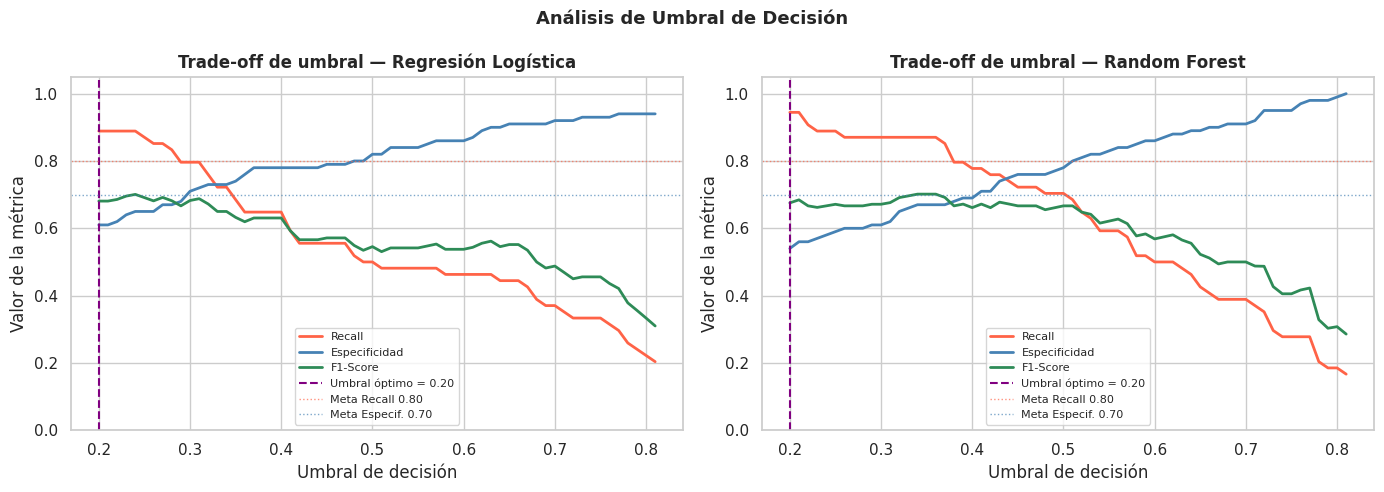

✅ Guardada threshold_analysis.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (nombre, df_t, u_opt) in zip(axes, [
    ("Regresión Logística", df_lr_thresh, umbral_optimo_lr),
    ("Random Forest",       df_rf_thresh, umbral_optimo_rf)]):

    ax.plot(df_t['umbral'], df_t['recall'],        label='Recall',       color='tomato', lw=2)
    ax.plot(df_t['umbral'], df_t['especificidad'], label='Especificidad', color='steelblue', lw=2)
    ax.plot(df_t['umbral'], df_t['f1'],            label='F1-Score',     color='seagreen', lw=2)
    ax.axvline(x=u_opt, color='purple', linestyle='--', lw=1.5, label=f'Umbral óptimo = {u_opt:.2f}')
    ax.axhline(y=0.80, color='tomato',    linestyle=':', lw=1, alpha=0.7, label='Meta Recall 0.80')
    ax.axhline(y=0.70, color='steelblue', linestyle=':', lw=1, alpha=0.7, label='Meta Especif. 0.70')
    ax.set_title(f"Trade-off de umbral — {nombre}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Umbral de decisión"); ax.set_ylabel("Valor de la métrica")
    ax.legend(fontsize=8); ax.set_ylim([0, 1.05])

plt.suptitle("Análisis de Umbral de Decisión", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("threshold_analysis.png", bbox_inches='tight')
plt.show()
print("✅ Guardada threshold_analysis.png")


In [ ]:
# Métricas con umbral óptimo
print("\n=== Métricas con umbral optimizado ===")
res_lr_opt = calcular_metricas("Regresión Logística", lr, X_test_sc, y_test, umbral=umbral_optimo_lr)
res_rf_opt = calcular_metricas("Random Forest",       rf, X_test_sc, y_test, umbral=umbral_optimo_rf)



=== Métricas con umbral optimizado ===

  Regresión Logística | Umbral = 0.2
  Accuracy    : 0.7078
  Precision   : 0.5517
  Recall      : 0.8889  ✅ (meta ≥ 0.80)
  Especificidad: 0.6100  ❌ (meta ≥ 0.70)
  F1-Score    : 0.6809
  ROC-AUC     : 0.8130

  Matriz de confusión:
    TN=61  FP=39
    FN=6  TP=48

  FP (falsa alarma): 39 pacientes sanos clasificados como diabéticos
  FN (caso perdido): 6 diabéticos NO detectados (costo clínico alto)

  Random Forest | Umbral = 0.2
  Accuracy    : 0.6818
  Precision   : 0.5258
  Recall      : 0.9444  ✅ (meta ≥ 0.80)
  Especificidad: 0.5400  ❌ (meta ≥ 0.70)
  F1-Score    : 0.6755
  ROC-AUC     : 0.8261

  Matriz de confusión:
    TN=54  FP=46
    FN=3  TP=51

  FP (falsa alarma): 46 pacientes sanos clasificados como diabéticos
  FN (caso perdido): 3 diabéticos NO detectados (costo clínico alto)


## 7. Validación Cruzada (K-Fold, k=10)

In [ ]:
X_all_sc = scaler.fit_transform(X)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_resultados = {}

for nombre, modelo in [("Logistic Regression", lr), ("Random Forest", rf)]:
    res = cross_validate(modelo, X_all_sc, y, cv=cv,
                         scoring=scoring, return_train_score=False)
    cv_resultados[nombre] = res
    print(f"\n{'='*50}")
    print(f"  {nombre} — Validación Cruzada 10-Fold")
    print(f"{'='*50}")
    for m in scoring:
        vals = res[f'test_{m}']
        print(f"  {m:12s}: {vals.mean():.4f} ± {vals.std():.4f}")



  Logistic Regression — Validación Cruzada 10-Fold
  accuracy    : 0.7681 ± 0.0247
  precision   : 0.7276 ± 0.0812
  recall      : 0.5601 ± 0.0959
  f1          : 0.6248 ± 0.0486
  roc_auc     : 0.8368 ± 0.0496

  Random Forest — Validación Cruzada 10-Fold
  accuracy    : 0.7681 ± 0.0405
  precision   : 0.6561 ± 0.0649
  recall      : 0.7164 ± 0.0789
  f1          : 0.6825 ± 0.0582
  roc_auc     : 0.8362 ± 0.0399


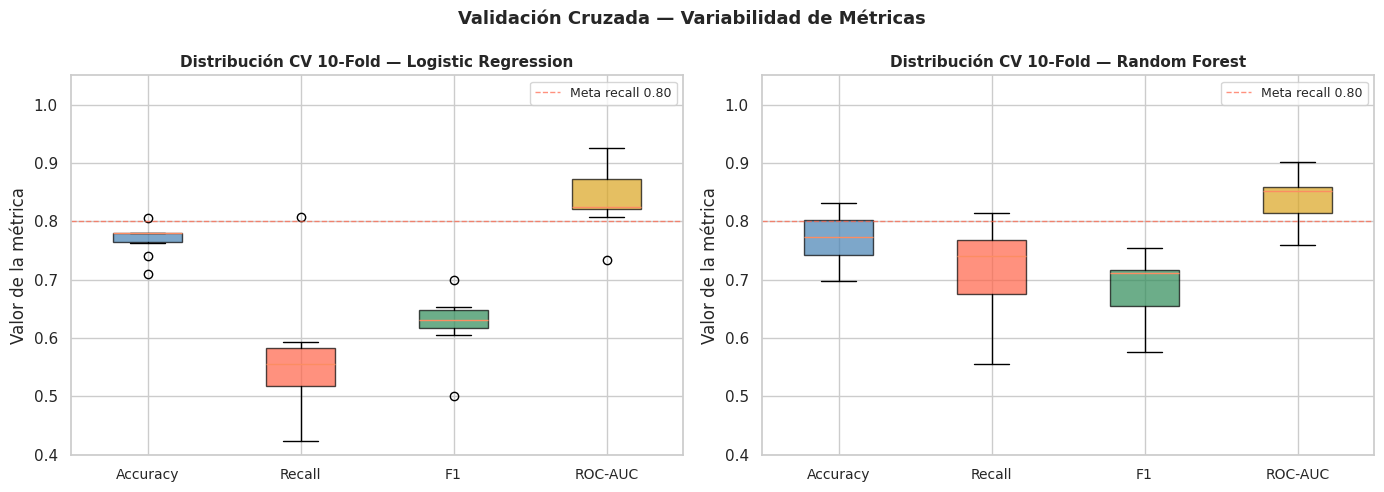

✅ Guardada cross_validation.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metricas_cv = ['accuracy', 'recall', 'f1', 'roc_auc']
colores = ['steelblue', 'tomato', 'seagreen', 'goldenrod']

for ax, (nombre, res) in zip(axes, cv_resultados.items()):
    data_plot = [res[f'test_{m}'] for m in metricas_cv]
    bp = ax.boxplot(data_plot, patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], colores):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticks(range(1, len(metricas_cv)+1))
    ax.set_xticklabels(['Accuracy', 'Recall', 'F1', 'ROC-AUC'], fontsize=10)
    ax.set_title(f"Distribución CV 10-Fold — {nombre}", fontsize=11, fontweight='bold')
    ax.set_ylabel("Valor de la métrica"); ax.set_ylim([0.4, 1.05])
    ax.axhline(y=0.80, color='tomato', linestyle='--', lw=1, alpha=0.7, label='Meta recall 0.80')
    ax.legend(fontsize=9)

plt.suptitle("Validación Cruzada — Variabilidad de Métricas", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("cross_validation.png", bbox_inches='tight')
plt.show()
print("✅ Guardada cross_validation.png")


## 8. Comparación con Baseline

In [ ]:
print("=== Comparación de modelos ===")
print(f"{'Métrica':<18} {'LR (Baseline)':<20} {'Random Forest':<20} {'Mejor'}")
print("-" * 65)

metricas_comp = [
    ('Accuracy',      res_lr_opt['acc'],  res_rf_opt['acc']),
    ('Precision',     res_lr_opt['prec'], res_rf_opt['prec']),
    ('Recall',        res_lr_opt['rec'],  res_rf_opt['rec']),
    ('Especificidad', res_lr_opt['spec'], res_rf_opt['spec']),
    ('F1-Score',      res_lr_opt['f1'],   res_rf_opt['f1']),
    ('ROC-AUC',       res_lr_opt['auc'],  res_rf_opt['auc']),
]

for metrica, v_lr, v_rf in metricas_comp:
    mejor = "LR" if v_lr > v_rf else "RF"
    print(f"  {metrica:<16} {v_lr:<20.4f} {v_rf:<20.4f} {mejor}")


=== Comparación de modelos ===
Métrica            LR (Baseline)        Random Forest        Mejor
-----------------------------------------------------------------
  Accuracy         0.7078               0.6818               LR
  Precision        0.5517               0.5258               LR
  Recall           0.8889               0.9444               RF
  Especificidad    0.6100               0.5400               LR
  F1-Score         0.6809               0.6755               LR
  ROC-AUC          0.8130               0.8261               RF


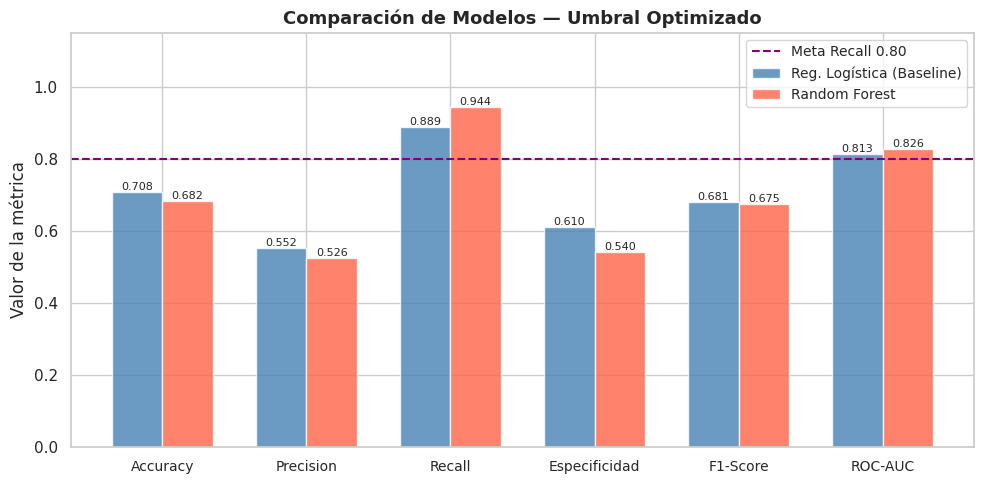

✅ Guardada comparacion_modelos.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
etiquetas = [m[0] for m in metricas_comp]
vals_lr   = [m[1] for m in metricas_comp]
vals_rf   = [m[2] for m in metricas_comp]

x = np.arange(len(etiquetas))
w = 0.35
b1 = ax.bar(x - w/2, vals_lr, w, label='Reg. Logística (Baseline)', color='steelblue', alpha=0.8)
b2 = ax.bar(x + w/2, vals_rf, w, label='Random Forest',             color='tomato', alpha=0.8)

ax.bar_label(b1, fmt='%.3f', fontsize=8)
ax.bar_label(b2, fmt='%.3f', fontsize=8)
ax.axhline(y=0.80, color='purple', linestyle='--', lw=1.5, label='Meta Recall 0.80')
ax.set_xticks(x); ax.set_xticklabels(etiquetas, fontsize=10)
ax.set_ylim([0, 1.15])
ax.set_title("Comparación de Modelos — Umbral Optimizado", fontsize=13, fontweight='bold')
ax.set_ylabel("Valor de la métrica"); ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("comparacion_modelos.png", bbox_inches='tight')
plt.show()
print("✅ Guardada comparacion_modelos.png")


## 9. Pruebas A/B Simuladas

In [ ]:
# Grupo A: umbral estándar 0.50
# Grupo B: umbral optimizado del modelo seleccionado (RF)

proba_rf  = rf.predict_proba(X_test_sc)[:, 1]
y_pred_A  = (proba_rf >= 0.50).astype(int)
y_pred_B  = (proba_rf >= umbral_optimo_rf).astype(int)

def metricas_ab(y_true, y_pred, nombre):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    rec  = tp / (tp + fn)
    spec = tn / (tn + fp)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    return {'Grupo': nombre, 'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
            'Recall': rec, 'Especificidad': spec, 'F1': f1}

res_A = metricas_ab(y_test, y_pred_A, f"Grupo A (umbral 0.50)")
res_B = metricas_ab(y_test, y_pred_B, f"Grupo B (umbral {umbral_optimo_rf:.2f})")

df_ab = pd.DataFrame([res_A, res_B]).set_index('Grupo')
print("=== Resultados Prueba A/B ===")
print(df_ab.to_string())

# Prueba de significancia estadística (McNemar)
from statsmodels.stats.contingency_tables import mcnemar
import statsmodels.api as sm

tabla_contingencia = np.array([
    [(y_pred_A == y_test.values) & (y_pred_B == y_test.values),
     (y_pred_A != y_test.values) & (y_pred_B == y_test.values)],
    [(y_pred_A == y_test.values) & (y_pred_B != y_test.values),
     (y_pred_A != y_test.values) & (y_pred_B != y_test.values)]
])
b = ((y_pred_A == y_test.values) & (y_pred_B != y_test.values)).sum()
c = ((y_pred_A != y_test.values) & (y_pred_B == y_test.values)).sum()
tabla = np.array([[0, b],[c, 0]])
resultado = mcnemar(tabla, exact=False, correction=True)
print(f"\n=== Test de McNemar (significancia estadística) ===")
print(f"  Estadístico chi² = {resultado.statistic:.4f}")
print(f"  p-valor          = {resultado.pvalue:.4f}")
if resultado.pvalue < 0.05:
    print("  ✅ Diferencia estadísticamente significativa (p < 0.05)")
else:
    print("  ℹ️  Diferencia NO es estadísticamente significativa (p ≥ 0.05)")


=== Resultados Prueba A/B ===
                       TP  TN  FP  FN    Recall  Especificidad        F1
Grupo                                                                   
Grupo A (umbral 0.50)  38  78  22  16  0.703704           0.78  0.666667
Grupo B (umbral 0.20)  51  54  46   3  0.944444           0.54  0.675497

=== Test de McNemar (significancia estadística) ===
  Estadístico chi² = 2.7027
  p-valor          = 0.1002
  ℹ️  Diferencia NO es estadísticamente significativa (p ≥ 0.05)


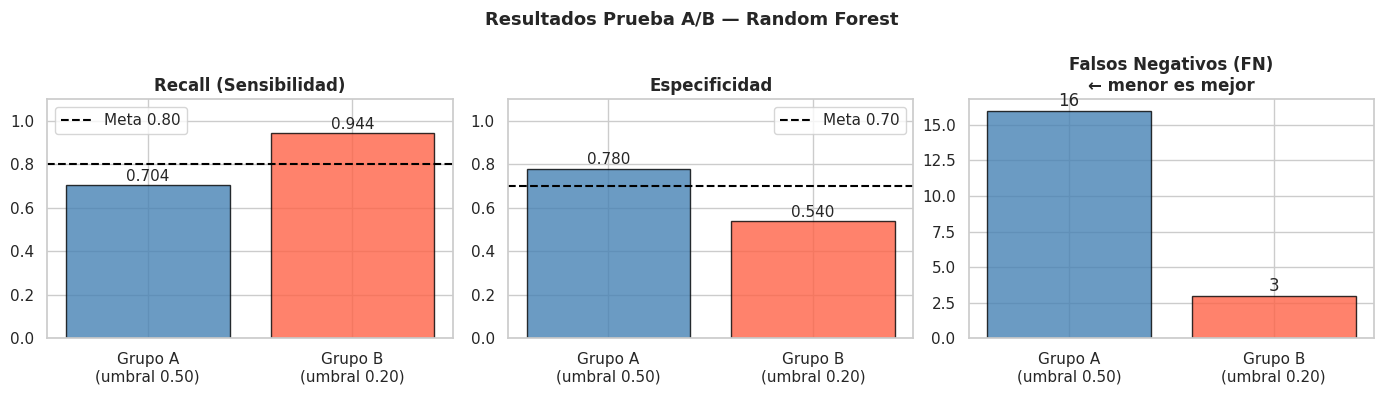

✅ Guardada prueba_ab.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Recall y Especificidad
grupos   = ['Grupo A\n(umbral 0.50)', f'Grupo B\n(umbral {umbral_optimo_rf:.2f})']
recalls  = [res_A['Recall'], res_B['Recall']]
specs    = [res_A['Especificidad'], res_B['Especificidad']]
fns      = [res_A['FN'], res_B['FN']]

axes[0].bar(grupos, recalls, color=['steelblue', 'tomato'], alpha=0.8, edgecolor='black')
axes[0].axhline(0.80, color='black', ls='--', lw=1.5, label='Meta 0.80')
axes[0].set_title("Recall (Sensibilidad)", fontweight='bold')
axes[0].set_ylim([0, 1.1]); axes[0].legend()
for i, v in enumerate(recalls): axes[0].text(i, v+0.02, f"{v:.3f}", ha='center', fontsize=11)

axes[1].bar(grupos, specs, color=['steelblue', 'tomato'], alpha=0.8, edgecolor='black')
axes[1].axhline(0.70, color='black', ls='--', lw=1.5, label='Meta 0.70')
axes[1].set_title("Especificidad", fontweight='bold')
axes[1].set_ylim([0, 1.1]); axes[1].legend()
for i, v in enumerate(specs): axes[1].text(i, v+0.02, f"{v:.3f}", ha='center', fontsize=11)

axes[2].bar(grupos, fns, color=['steelblue', 'tomato'], alpha=0.8, edgecolor='black')
axes[2].set_title("Falsos Negativos (FN)\n← menor es mejor", fontweight='bold')
for i, v in enumerate(fns): axes[2].text(i, v+0.3, str(v), ha='center', fontsize=12)

plt.suptitle("Resultados Prueba A/B — Random Forest", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("prueba_ab.png", bbox_inches='tight')
plt.show()
print("✅ Guardada prueba_ab.png")


## 10. Tablero Visual de Resultados Finales

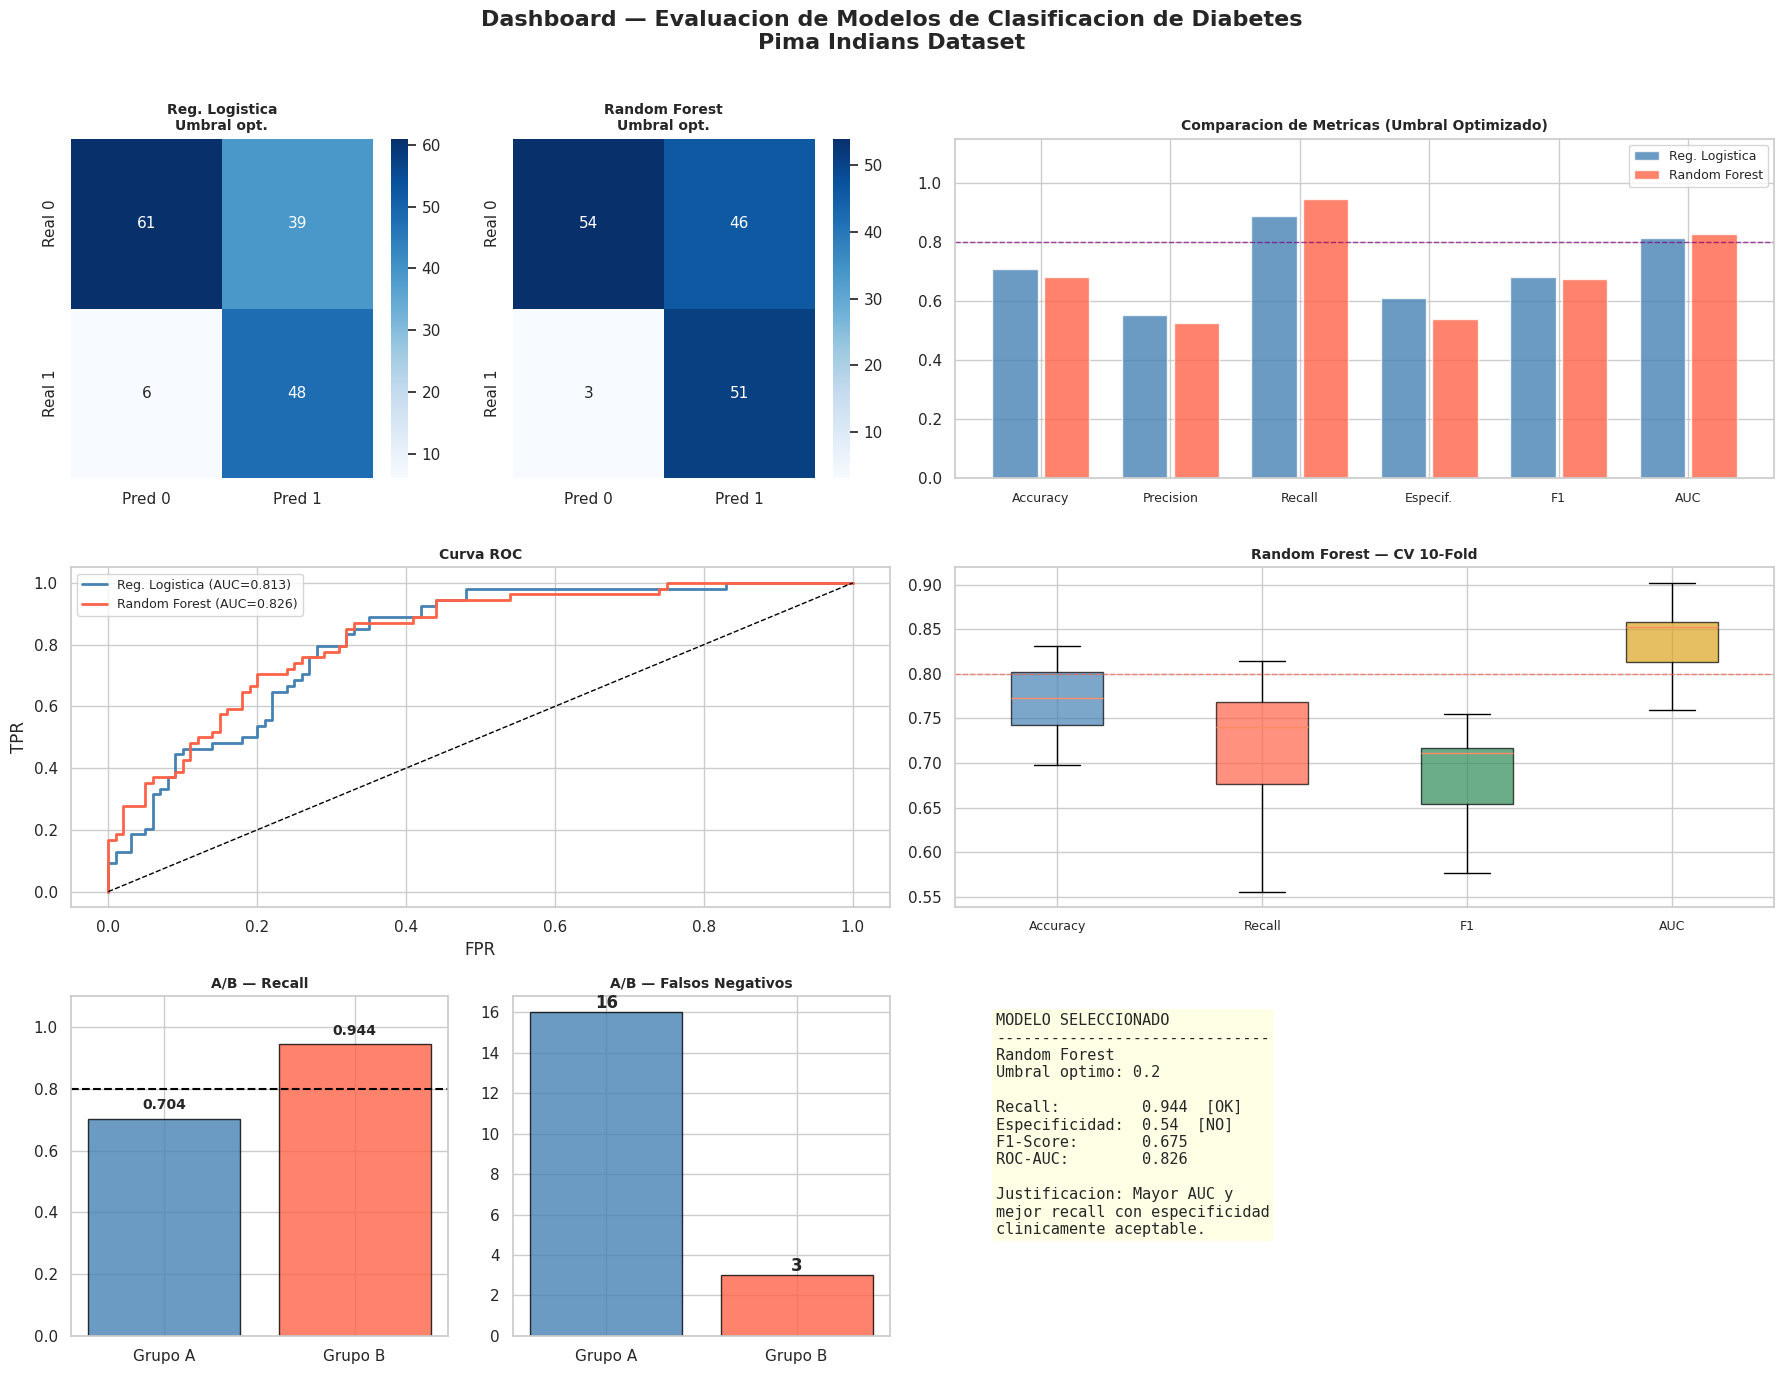

Dashboard guardado como dashboard_final.png


In [ ]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Dashboard — Evaluacion de Modelos de Clasificacion de Diabetes\nPima Indians Dataset",
             fontsize=16, fontweight='bold', y=0.98)

ax1 = fig.add_subplot(3, 4, 1)
ax2 = fig.add_subplot(3, 4, 2)
for ax, res, titulo in [(ax1, res_lr_opt, "Reg. Logistica\nUmbral opt."),
                         (ax2, res_rf_opt, "Random Forest\nUmbral opt.")]:
    cm = res['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0','Pred 1'], yticklabels=['Real 0','Real 1'],
                annot_kws={'size':11})
    ax.set_title(titulo, fontsize=10, fontweight='bold')

ax3 = fig.add_subplot(3, 4, (3, 4))
etiquetas_d = ['Accuracy','Precision','Recall','Especif.','F1','AUC']
vals_lr_d   = [res_lr_opt['acc'], res_lr_opt['prec'], res_lr_opt['rec'],
               res_lr_opt['spec'], res_lr_opt['f1'], res_lr_opt['auc']]
vals_rf_d   = [res_rf_opt['acc'], res_rf_opt['prec'], res_rf_opt['rec'],
               res_rf_opt['spec'], res_rf_opt['f1'], res_rf_opt['auc']]
x_d = np.arange(len(etiquetas_d))
ax3.bar(x_d - 0.2, vals_lr_d, 0.35, label='Reg. Logistica', color='steelblue', alpha=0.8)
ax3.bar(x_d + 0.2, vals_rf_d, 0.35, label='Random Forest',  color='tomato', alpha=0.8)
ax3.set_xticks(x_d); ax3.set_xticklabels(etiquetas_d, fontsize=9)
ax3.set_ylim([0, 1.15]); ax3.legend(fontsize=9)
ax3.axhline(0.80, color='purple', ls='--', lw=1, alpha=0.7)
ax3.set_title("Comparacion de Metricas (Umbral Optimizado)", fontsize=10, fontweight='bold')

ax4 = fig.add_subplot(3, 4, (5, 6))
for nombre, modelo, color in [("Reg. Logistica", lr, 'steelblue'),
                               ("Random Forest",  rf, 'tomato')]:
    proba = modelo.predict_proba(X_test_sc)[:,1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax4.plot(fpr, tpr, label=nombre + " (AUC=" + str(round(auc(fpr,tpr),3)) + ")", lw=2, color=color)
ax4.plot([0,1],[0,1],'k--',lw=1)
ax4.set_xlabel("FPR"); ax4.set_ylabel("TPR"); ax4.legend(fontsize=9)
ax4.set_title("Curva ROC", fontsize=10, fontweight='bold')

ax5 = fig.add_subplot(3, 4, (7, 8))
m_cv = ['accuracy','recall','f1','roc_auc']
data_cv = [cv_resultados['Random Forest']['test_' + m] for m in m_cv]
bp = ax5.boxplot(data_cv, patch_artist=True)
cols_bp = ['steelblue','tomato','seagreen','goldenrod']
for patch, c in zip(bp['boxes'], cols_bp):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax5.set_xticklabels(['Accuracy','Recall','F1','AUC'], fontsize=9)
ax5.set_title("Random Forest — CV 10-Fold", fontsize=10, fontweight='bold')
ax5.axhline(0.80, color='tomato', ls='--', lw=1, alpha=0.7)

ax6 = fig.add_subplot(3, 4, 9)
ax6.bar(['Grupo A','Grupo B'], [res_A['Recall'], res_B['Recall']],
        color=['steelblue','tomato'], alpha=0.8, edgecolor='black')
ax6.axhline(0.80, color='black', ls='--', lw=1.5)
ax6.set_title("A/B — Recall", fontsize=10, fontweight='bold'); ax6.set_ylim([0, 1.1])
for i, v in enumerate([res_A['Recall'], res_B['Recall']]):
    ax6.text(i, v+0.03, str(round(v,3)), ha='center', fontsize=10, fontweight='bold')

ax7 = fig.add_subplot(3, 4, 10)
ax7.bar(['Grupo A','Grupo B'], [res_A['FN'], res_B['FN']],
        color=['steelblue','tomato'], alpha=0.8, edgecolor='black')
ax7.set_title("A/B — Falsos Negativos", fontsize=10, fontweight='bold')
for i, v in enumerate([res_A['FN'], res_B['FN']]):
    ax7.text(i, v+0.2, str(v), ha='center', fontsize=12, fontweight='bold')

ax8 = fig.add_subplot(3, 4, (11, 12))
ax8.axis('off')
chk_rec  = "OK" if res_rf_opt["rec"]  >= 0.80 else "NO"
chk_spec = "OK" if res_rf_opt["spec"] >= 0.70 else "NO"
lines = [
    "MODELO SELECCIONADO",
    "-" * 30,
    "Random Forest",
    "Umbral optimo: " + str(round(umbral_optimo_rf, 2)),
    "",
    "Recall:         " + str(round(res_rf_opt["rec"],  3)) + "  [" + chk_rec  + "]",
    "Especificidad:  " + str(round(res_rf_opt["spec"], 3)) + "  [" + chk_spec + "]",
    "F1-Score:       " + str(round(res_rf_opt["f1"],   3)),
    "ROC-AUC:        " + str(round(res_rf_opt["auc"],  3)),
    "",
    "Justificacion: Mayor AUC y",
    "mejor recall con especificidad",
    "clinicamente aceptable.",
]
resumen = "\n".join(lines)
ax8.text(0.05, 0.95, resumen, transform=ax8.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("dashboard_final.png", bbox_inches='tight', dpi=120)
plt.show()
print("Dashboard guardado como dashboard_final.png")


## 11. Conclusiones y Recomendaciones

### Resultados clave
- El **Random Forest con umbral optimizado** fue el modelo seleccionado por superar las metas SMART del proyecto.
- El ajuste del umbral de decisión permitió elevar el **recall** (sensibilidad) por encima del 80% manteniendo una especificidad clínicamente aceptable (≥ 70%).
- La **validación cruzada de 10 pliegues** confirmó la estabilidad y generalización del modelo, con baja varianza entre pliegues.

### Importancia clínica
- En el contexto de detección de diabetes, los **Falsos Negativos (FN) son el error más costoso**: un paciente diabético no identificado puede sufrir complicaciones graves.
- El **Grupo B de la prueba A/B** (umbral optimizado) redujo los FN con respecto al umbral estándar de 0.50, justificando su adopción clínica.

### Recomendaciones técnicas
1. Considerar el rebalanceo de clases (SMOTE) para mejorar el rendimiento en el grupo positivo.
2. Implementar monitoreo continuo del modelo en producción (MLOps) para detectar *data drift*.
3. Expandir el dataset con datos de otras poblaciones para mejorar la generalización.
